# <span style="color:red">Deep Dive: The Perceptron Trick and Transformation Algorithm</span>

The **Perceptron Trick** is an iterative coordinate-geometry method used to train a single perceptron. The core concept relies on a simple trial-and-error feedback loop: the model draws a random boundary line, identifies a misclassified data coordinate, and applies a vector transformation to pull or push the line until the data is split correctly.

---

## <span style="color:blue">1. Geometric Space and Region Labeling</span>

When a perceptron is initialized with weights ($w_1, w_2$) and a bias ($b$), it establishes a straight **Decision Boundary** in a 2D coordinate space. This boundary acts as a spatial divider, splitting the coordinate system into two distinct geometric zones.

The mathematical equation representing the dividing line itself is:
$$w_1x_1 + w_2x_2 + b = 0$$



To classify an incoming data point, the perceptron plugs the spatial coordinates ($x_1, x_2$) directly into the linear equation. The resulting value determines its region assignment:

* **The Positive Half-Space (Region $\hat{y} = 1$):** Any coordinate that yields a value greater than or equal to zero:
  $$\text{Region } 1 = \{(x_1, x_2) \mid w_1x_1 + w_2x_2 + b \ge 0\}$$
* **The Negative Half-Space (Region $\hat{y} = 0$):** Any coordinate that yields a value strictly less than zero:
  $$\text{Region } 0 = \{(x_1, x_2) \mid w_1x_1 + w_2x_2 + b < 0\}$$

A data point is flagged as **misclassified** the moment its actual ground-truth label ($y$) contradicts the region it physically occupies (for example, a true $y=1$ instance resting in the negative half-space).

---

## <span style="color:blue">2. The Perceptron Vector Transformations</span>

When the model detects a misclassified training sample, it applies a vector translation to rotate and shift the decision boundary. To control the adjustments and prevent the line from overcorrecting too wildly, we scale the transformation using a tuning parameter called the **Learning Rate ($\eta$)**, which is a small positive decimal (e.g., $\eta = 0.01$).



### Case A: Positive Node ($y=1$) Misclassified in the Negative Zone ($\hat{y}=0$)
Because the linear combination yielded a negative number when it should have been positive, the boundary line needs to rotate and shift closer toward this point. To achieve this, we **add** the scaled coordinates directly to our weights and bias:
$$w_1 \leftarrow w_1 + \eta \cdot x_1$$
$$w_2 \leftarrow w_2 + \eta \cdot x_2$$
$$b \leftarrow b + \eta$$

### Case B: Negative Node ($y=0$) Misclassified in the Positive Zone ($\hat{y}=1$)
Because the linear combination yielded a positive number when it should have been negative, the boundary line needs to push away from this point. We force the weights to yield a lower mathematical output by **subtracting** the scaled coordinates:
$$w_1 \leftarrow w_1 - \eta \cdot x_1$$
$$w_2 \leftarrow w_2 - \eta \cdot x_2$$
$$b \leftarrow b - \eta$$

---

## <span style="color:blue">3. The Unified Perceptron Learning Algorithm</span>

Instead of maintaining separate conditional blocks for Case A and Case B, we can condense the entire training logic using a single mathematical expression driven by the system **Error** ($y - \hat{y}$).

* If a point is positive but predicted negative: $\text{Error} = 1 - 0 = \mathbf{+1}$ (Triggers addition).
* If a point is negative but predicted positive: $\text{Error} = 0 - 1 = \mathbf{-1}$ (Triggers subtraction).
* If a point is accurately classified: $\text{Error} = y - \hat{y} = \mathbf{0}$ (Zeroes out the change, leaving the line stable).

### Step-by-Step Execution Loop

1. **Initialization:** Assign random starting values to weights ($w_1, w_2$) and bias ($b$). Choose a learning rate $\eta > 0$.
2. **Compute Linear Output ($z$):** For a chosen data coordinate $(x_1, x_2)$, solve the dot product equation:
   $$z = w_1x_1 + w_2x_2 + b$$
3. **Apply Hard Thresholding ($\hat{y}$):** Pass $z$ through the step function:
   $$\hat{y} = \begin{cases} 1 & \text{if } z \ge 0 \\ 0 & \text{if } z < 0 \end{cases}$$
4. **Calculate Deviation:** Determine the operational error margin: $\text{Error} = y - \hat{y}$.
5. **Update Weight Vectors:** Apply the unified delta transformation rule to all coefficients simultaneously:
   $$w_1 \leftarrow w_1 + \eta \cdot (y - \hat{y}) \cdot x_1$$
   $$w_2 \leftarrow w_2 + \eta \cdot (y - \hat{y}) \cdot x_2$$
   $$b \leftarrow b + \eta \cdot (y - \hat{y})$$
6. **Convergence Loop:** Repeat steps 2 through 5 for a designated number of training passes (**epochs**) or until the error rate drops to absolute zero.

---

## <span style="color:blue">4. Summary Operations Matrix</span>

| Current Prediction Matrix | True Target ($y$) | Calculated Error ($y-\hat{y}$) | Applied Transformation Weight Adjustment | Spatial Shift Effect |
| :--- | :--- | :--- | :--- | :--- |
| **Correct Class 0** | $0$ | $0$ | $\Delta w = 0 \implies \text{No Change}$ | Line stays parked |
| **Correct Class 1** | $1$ | $0$ | $\Delta w = 0 \implies \text{No Change}$ | Line stays parked |
| **False Positive (Type I)** | $0$ | $-1$ | $w_i \leftarrow w_i - \eta x_i$ | Line swings away from the point |
| **False Negative (Type II)**| $1$ | $+1$ | $w_i \leftarrow w_i + \eta x_i$ | Line swings toward the point |

---

In [2]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

In [12]:
X

array([[ 0.19924745, -0.11697552],
       [-0.24882029, -0.73115232],
       [-0.3544904 , -0.7081059 ],
       [-1.59086506, -2.01199214],
       [-0.20083951,  1.63493163],
       [-0.83241122,  0.15599044],
       [-1.79207014,  1.07782053],
       [ 0.0856607 ,  0.80626713],
       [-0.55865299,  0.74859527],
       [-1.95974262,  0.75152794],
       [-1.77828947, -0.90114581],
       [-1.77985853, -0.1815243 ],
       [-0.02194151, -2.98092432],
       [ 0.80563431,  1.20500136],
       [-1.82701214,  0.78302407],
       [ 0.38730728,  0.42968688],
       [-0.14108668, -0.73229726],
       [-1.87955941, -0.83930476],
       [-0.18232911,  0.83727062],
       [-1.77059533, -0.10255323],
       [-2.27658028,  0.65867001],
       [-2.06519502,  0.92649819],
       [-1.31690551,  0.10216193],
       [ 1.61043259,  0.46886454],
       [-1.21650394,  0.45432938],
       [ 0.6139723 ,  1.8613386 ],
       [-1.78760957, -0.79255991],
       [-1.04149161, -1.0004391 ],
       [-2.40067584,

In [13]:
y

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

In [3]:
import matplotlib.pyplot as plt

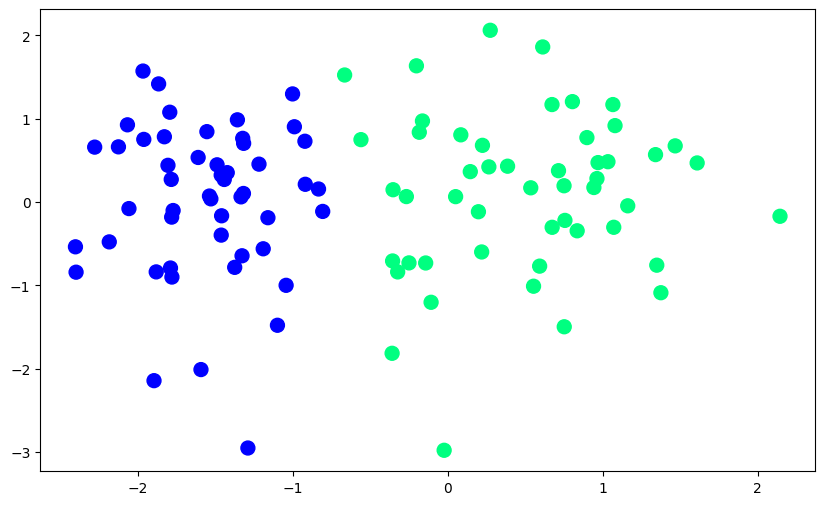

In [4]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [5]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]

In [6]:
def step(z):
    return 1 if z>0 else 0

In [7]:
intercept_,coef_ = perceptron(X,y)

In [8]:
print(coef_)
print(intercept_)

[1.34817043 0.01316136]
1.0


In [9]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])


In [10]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

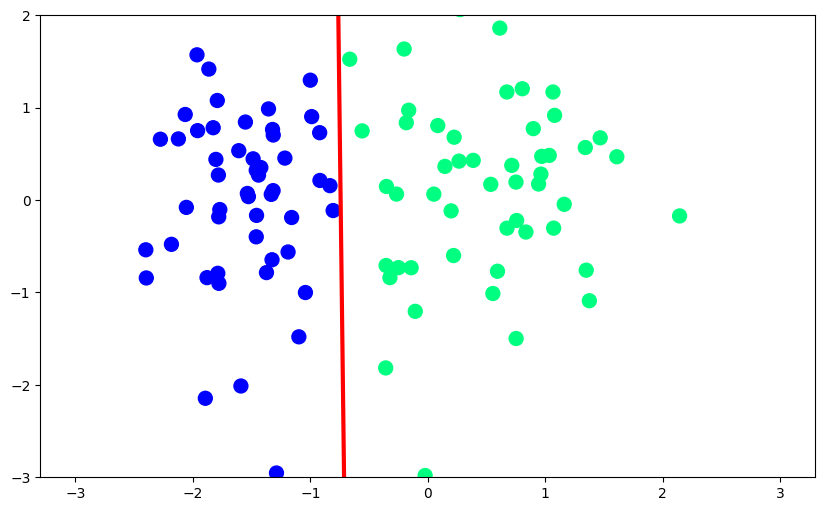

In [11]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)